In [1]:
# https://gemini.google.com/app/5109b1ed662b462a


import os
import subprocess
try:
    _printenv = subprocess.run(
        ['bash', '-c', 'source ~/.bashrc 2>/dev/null && printenv'],
        text=True, capture_output=True, timeout=10,
    ).stdout
    for _line in _printenv.splitlines():
        if '=' in _line:
            _k, _v = _line.split('=', 1)
            os.environ.setdefault(_k, _v)
except Exception:
    pass
if 'PDK_ROOT' in os.environ and 'PDK' in os.environ:
    os.environ.setdefault('PDKPATH', os.path.join(os.environ['PDK_ROOT'], os.environ['PDK']))

import gdstk
import svgutils.transform as sg
import IPython.display
from IPython.display import clear_output
import ipywidgets as widgets

# Redirect all outputs here
hide = widgets.Output()

def display_gds(gds_file,path,scale = 3):
  
  # Generate an SVG image
  top_level_cell = gdstk.read_gds(gds_file).top_level()[0]
  top_level_cell.write_svg(os.path.join(path,'out.svg'))
    
  # Scale the image for displaying
  fig = sg.fromfile(os.path.join(path,'out.svg'))
  fig.set_size((str(float(fig.width) * scale), str(float(fig.height) * scale)))
  fig.save(os.path.join(path,'out.svg'))

  # Display the image
  IPython.display.display(IPython.display.SVG(os.path.join(path,'out.svg')))
  os.remove(os.path.join(path,'out.gds'))

def display_component(component,path,scale = 3):
  # Save to a GDS file
  with hide:
    component.write_gds(os.path.join(path,'out.gds'))
  display_gds(os.path.join(path,'out.gds'),path,scale)


# %%
import os
import gdsfactory as gf
from gdsfactory import Component
from glayout import MappedPDK, gf180
from glayout import nmos, pmos
from glayout import via_stack
from glayout import rename_ports_by_orientation
from glayout import tapring
from glayout.primitives.mimcap import mimcap_array
from glayout.routing.straight_route import straight_route
from glayout.routing.c_route import c_route
from glayout.routing.L_route import L_route
from glayout.util.comp_utils import evaluate_bbox, prec_center, prec_ref_center, align_comp_to_port
from glayout.util.port_utils import add_ports_perimeter,print_ports
from glayout.util.snap_to_grid import component_snap_to_grid
from glayout.spice.netlist import Netlist


# Base parameters for PMOS and NMOS
neurona_config = {
    "pdk": gf180,
    "layout_rules": {
        "spacing": gf180.util_max_metal_seperation()+1,
        "routing_metal": "met2",
        "dummy_devices": False,
        "tie_layers": ("met2", "met1"),
        "sd_rmult": 1,
    },
}

nmos_kwargs = {
    "with_tie": True,
    "with_dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2","met1"),
    "dummy_routes": False
}

pmos_kwargs = {
    "with_tie": True,
    "dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2","met1"),
    "dummy_routes": False
}


pdk = gf180
neurona_comp = Component(name="neurona_lvs")
neurona_comp.name = "neurona_lvs"
rules = neurona_config["layout_rules"]
spacing = rules["spacing"]
tie_layers = rules["tie_layers"]
sd_rmult = rules["sd_rmult"]


In [2]:
# Create transistor primitives based on .spice parameters
# M1, M3, M7: PMOS W=0.22u, L=0.28u, nf=1
m_p = pmos(pdk, width=0.5, length=0.28*2.27, with_dummy=(False, False), with_substrate_tap=False, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)

# M2, M4, M8: NMOS W=0.22u, L=0.28u, nf=1
m_n = nmos(pdk, width=0.5, length=0.28*2.27, with_dummy=(False, False), with_substrate_tap=False, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)

# M5: Reset NMOS W=1.25u, L=50u, nf=1 (Long channel device)
m5_reset = nmos(pdk, width=1.25, length=50.0, with_dummy=(False, False), with_substrate_tap=False, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)

# XC2: MIM Capacitor (3 parallel caps with 5u x 5u geometry)
cap_mim = mimcap_array(pdk, size=(5.0, 5.0), columns=3, rows=1)

# ==============================================================================
# PLACEMENT & INSTANTIATION
# ==============================================================================

# Row 1: PMOS Transistors (M1, M3, M7)
m1_ref = neurona_comp << m_p
m3_ref = neurona_comp << m_p
m7_ref = neurona_comp << m_p

# Row 2: Standard NMOS Transistors (M2, M4, M8) placed directly below PMOS
m2_ref = neurona_comp << m_n
m4_ref = neurona_comp << m_n
m8_ref = neurona_comp << m_n

# Placement: Reset NMOS (M5) - Long channel, placed below M2/M4
m5_ref = neurona_comp << m5_reset

# Placement: MIM Capacitor Array (XC2) - Placed adjacent to the inverter core
cap_ref = neurona_comp << cap_mim

m1_ref.name = "m1"
m3_ref.name = "m3"
m7_ref.name = "m7"
m2_ref.name = "m2"
m4_ref.name = "m4"
m8_ref.name = "m8"
m5_ref.name = "m5"
cap_ref.name = "cap"


# Ensure grid snap compliance
# neurona_comp = component_snap_to_grid(neurona_comp)


# Display rendered placement component
# display_component(stdp_comp, "./")

2026-08-10 22:06:26.859 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


In [ ]:

bottom_row = evaluate_bbox(m2_ref)[1]/2
middle_row = bottom_row + evaluate_bbox(m5_ref)[1]
top_row = middle_row + evaluate_bbox(m1_ref)[1] + 2 
m1_ref.move((0 + evaluate_bbox(m1_ref)[0]/2, top_row))
m3_ref.move((m1_ref.xmax + evaluate_bbox(m3_ref)[0]/2, top_row))
m7_ref.move((m3_ref.xmax + evaluate_bbox(m7_ref)[0]/2, top_row))

m2_ref.move((0 + evaluate_bbox(m2_ref)[0]/2, bottom_row))
m4_ref.move((m2_ref.xmax + evaluate_bbox(m4_ref)[0]/2, bottom_row))
m8_ref.move((m4_ref.xmax + evaluate_bbox(m8_ref)[0]/2, bottom_row))

cap_ref.move((m8_ref.xmax + evaluate_bbox(cap_ref)[0]/2, bottom_row))
m5_ref.move((0 + evaluate_bbox(m5_ref)[0]/2, middle_row))

ComponentReference (parent Component "Unnamed_54083600", ports ['multiplier_0_gate_W', 'gate_W', 'multiplier_0_row0_col0_gate_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_layer_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_via_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_bottom_met_W', 'multiplier_0_row0_col0_rightsd_array_row0_col0_top_met_W', 'multiplier_0_row0_col0_rightsd_top_met_W', 'multiplier_0_leftsd_array_row0_col0_bottom_layer_W', 'multiplier_0_leftsd_array_row0_col0_bottom_via_W', 'multiplier_0_leftsd_array_row0_col0_bottom_met_W', 'multiplier_0_leftsd_array_row0_col0_top_met_W', 'multiplier_0_leftsd_top_met_W', 'multiplier_0_plusdoped_W', 'multiplier_0_diff_W', 'multiplier_0_source_W', 'source_W', 'multiplier_0_drain_W', 'drain_W', 'multiplier_0_leftsd_array_row0_col0_bottom_layer_N', 'multiplier_0_leftsd_array_row0_col0_bottom_via_N', 'multiplier_0_leftsd_array_row0_col0_bottom_met_N', 'multiplier_0_leftsd_array_row0_col0_top_met_N', 'mult

2026-08-10 22:08:47.904 | WARNING  | gdsfactory.klive:show:48 - Could not connect to klive server. Is klayout open and klive plugin installed?


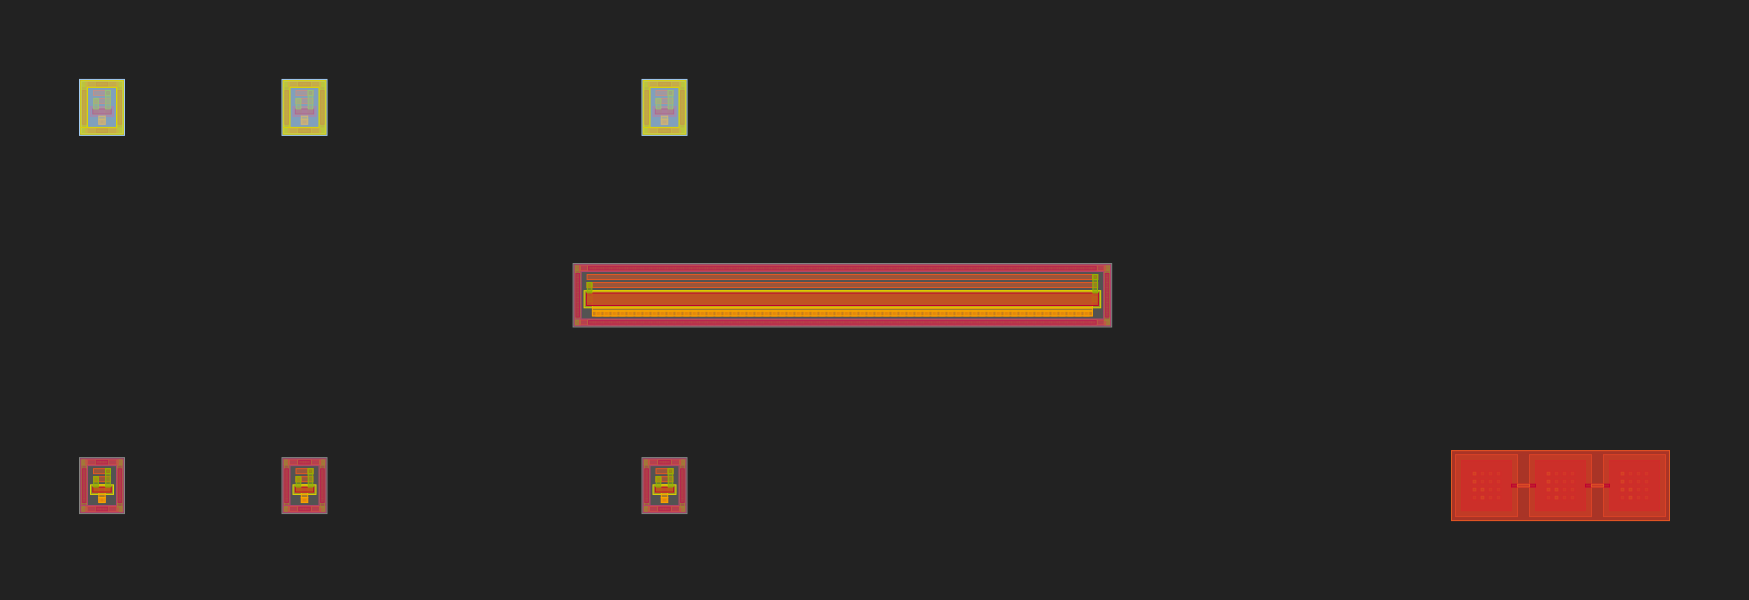

In [9]:
neurona_comp.show()
display_component(neurona_comp, scale = 1,path=".")

In [5]:
neurona_comp.write_gds(str("/foss/designs/libs/snn_analog/lif/neurona_lvs.gds"))

/tmp/ipykernel_987/945137832.py:1: UserWarning: Unnamed cells, 4 in 'neurona_lvs'
  neurona_comp.write_gds(str("/foss/designs/libs/snn_analog/lif/neurona_lvs.gds"))
2026-08-10 22:06:30.480 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/foss/designs/libs/snn_analog/lif/neurona_lvs.gds'


PosixPath('/foss/designs/libs/snn_analog/lif/neurona_lvs.gds')